In [ ]:
from functions import *
import numpy as np

"""
The difference between the best center and the second best center is large (on average eta_1-eta_2 ~ 1/(N_c+1), so the system is naturally almost
monocentric for small populations, and a Clark profile emerges

Z_ij = eta_j - (d_ij/l) * [1 + (T(j)/c)^mu]
"""

In [25]:
%%time

seed = 3531690

R = 6.0                              # city radius, km
inv_nc = 4                           # a center every inv_nc km^2
N_c = int(np.pi * R**2 / inv_nc)     # number of centers in the city, given the density of centers

c = 5_000.0                          # network capacity
mu = 4.0                             # exponent of the congestion term

s = 24_000.0                         # EUR/year
cost_per_km_trip = 1.5               # EUR/km
trips_per_year = 2 * 220
t_cost = cost_per_km_trip * trips_per_year
l = s / t_cost                


P_max = 2_000_000
n_bins = 80
r0_ker = np.sqrt(inv_nc)              # kernel density corresponds to the typical distance between centers

np.random.seed(seed)

P_star = P_star_theory(l, R, N_c, c, mu)
print(f"N_c={N_c}  l/R={l/R:.2f}  P*={P_star:.0f}  P_max={P_max:,}")

sampling='uniform'  # 'uniform' or 'clark'

cx, cy, eta, wx, wy, assignment, z_avg, z_std, dist_avg, dist_std = run_growth(P_max=P_max, N_c=N_c, R=R, l=l, c=c, mu=mu, k0_ker=r0_ker, sampling=sampling, seed=seed)

T_final = np.bincount(assignment, minlength=N_c).astype(float)  # how many workers to each center
print(f"\nk_final = {int((T_final>0).sum())}/{N_c}   top values: {np.sort(T_final)[::-1][:7].astype(np.uint32)}"
    f'\n Z_avg={z_avg:.2f}  \t Z_std={z_std:.2f} \n dist_avg={dist_avg:.2f} \t dist_std={dist_std:.2f}\n')

sampling='clark'  # 'uniform' or 'clark'
cx_clark, cy_clark, eta_clark, wx_clark, wy_clark, assignment_clark, z_avg_clark, z_std_clark, dist_avg_clark, dist_std_clark = run_growth(P_max=P_max, N_c=N_c, R=R, l=l, c=c, mu=mu, k0_ker=r0_ker, sampling=sampling, seed=seed)
T_final_clark = np.bincount(assignment_clark, minlength=N_c).astype(float)  # how many workers to each center
print(f"k_final = {int((T_final_clark>0).sum())}/{N_c}   top values: {np.sort(T_final_clark)[::-1][:7].astype(np.uint32)}"
    f'\nZ_avg={z_avg_clark:.2f} \t  Z_std={z_std_clark:.2f} \n dist_avg={dist_avg_clark:.2f} \t dist_std={dist_std_clark:.2f}\n')

N_c=28  l/R=6.06  P*=3410  P_max=2,000,000

k_final = 28/28   top values: [80027 79066 76711 76284 76084 74659 74028]
 Z_avg=-258.74  	 Z_std=432.92 
 dist_avg=1.23 	 dist_std=0.93

k_final = 28/28   top values: [83273 80069 79721 79705 79352 77226 76384]
Z_avg=-258.39 	  Z_std=449.65 
 dist_avg=1.18 	 dist_std=0.93

CPU times: user 3.84 s, sys: 39.5 ms, total: 3.88 s
Wall time: 3.88 s


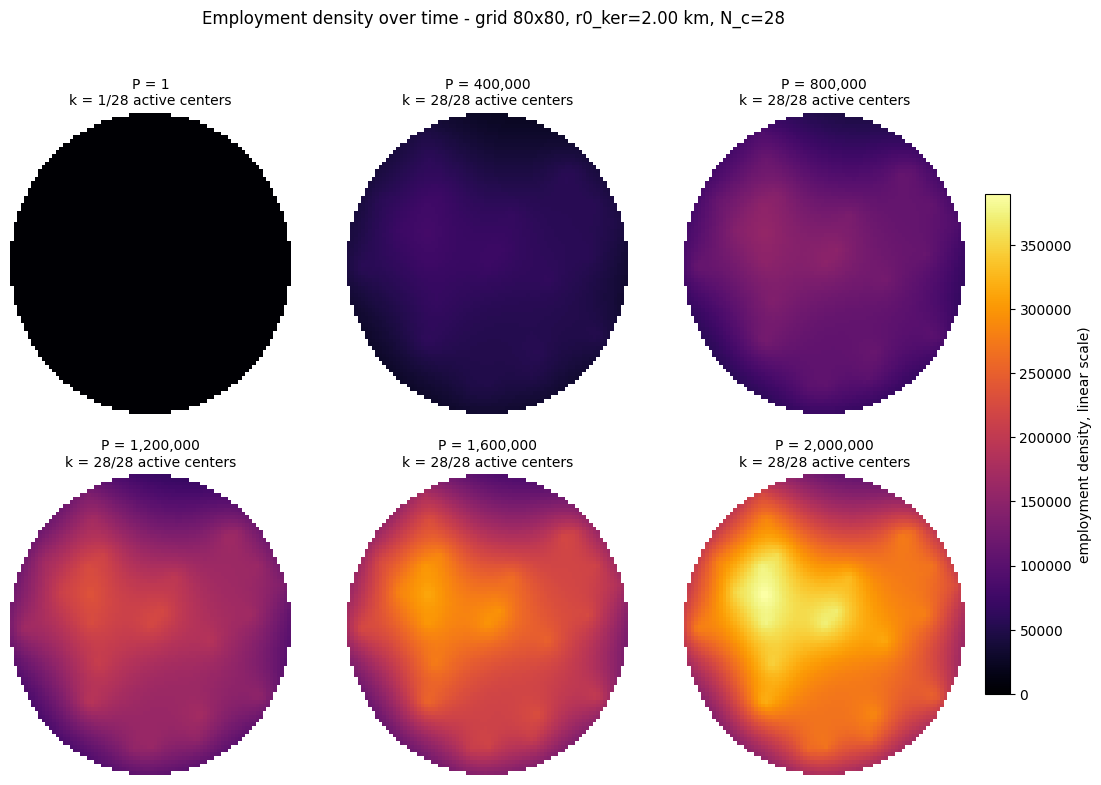

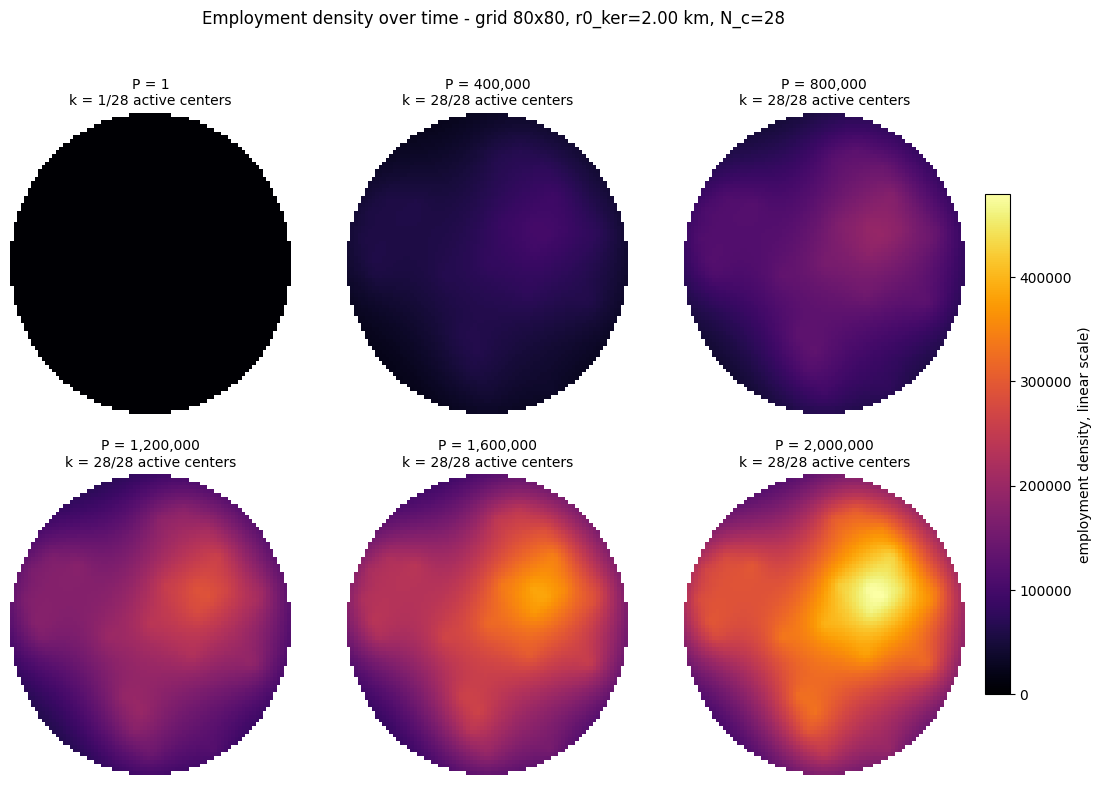

CPU times: user 1.1 s, sys: 7.22 ms, total: 1.1 s
Wall time: 847 ms


In [26]:
%%time
n_snapshots = 6
color_scale = "linear"      # "linear" or "log"
cmap_name = "inferno"

plot_density_evolution(cx, cy, assignment, N_c, R, n_bins, r0_ker,
                        n_snapshots=n_snapshots, color_scale=color_scale,
                        cmap_name=cmap_name, P_max=P_max)

plot_density_evolution(cx_clark, cy_clark, assignment_clark, N_c, R, n_bins, r0_ker,
                        n_snapshots=n_snapshots, color_scale=color_scale,
                        cmap_name=cmap_name, P_max=P_max)

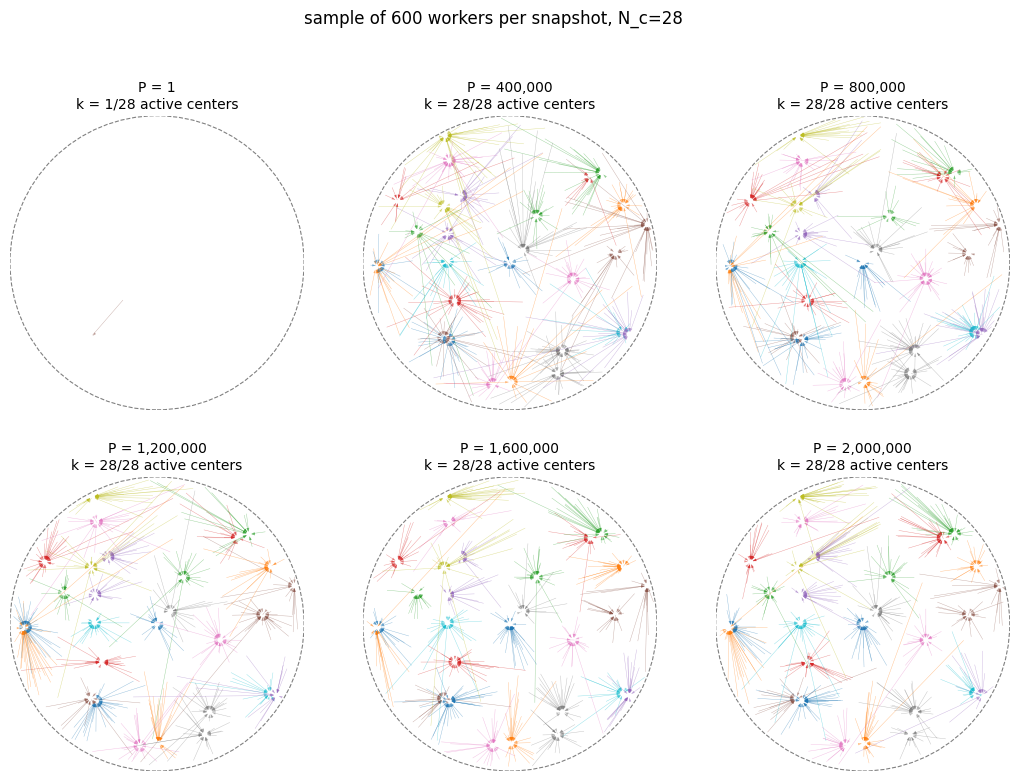

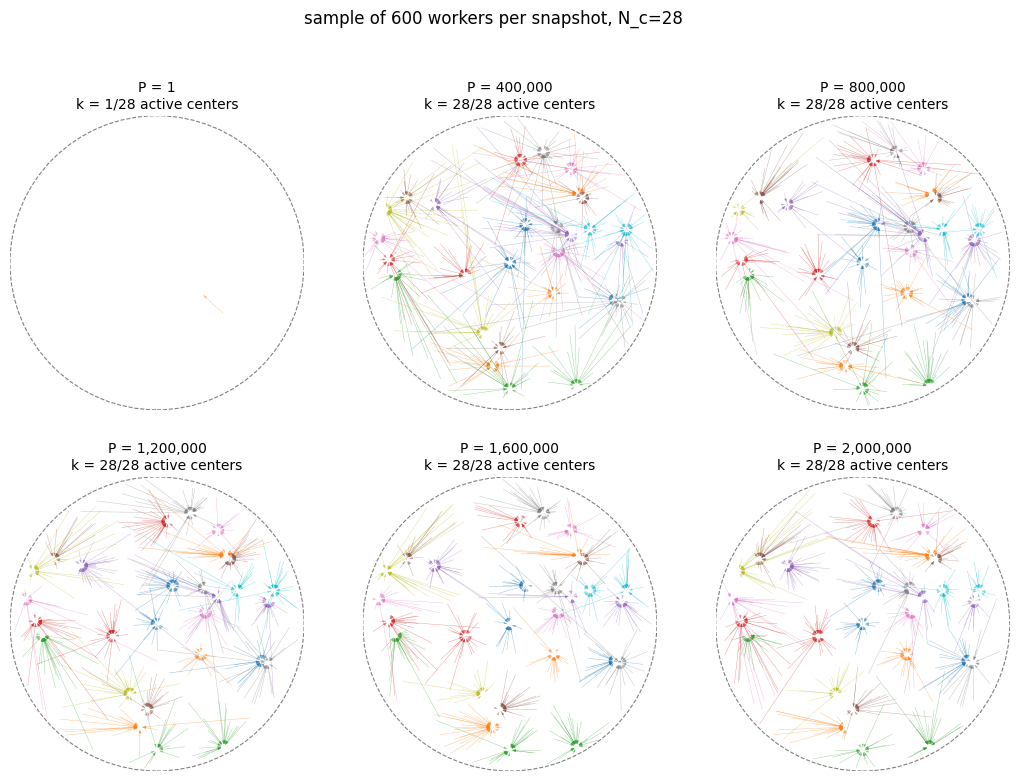

CPU times: user 1.68 s, sys: 8.76 ms, total: 1.69 s
Wall time: 1.7 s


In [27]:
%%time
n_snapshots_arrows = 6         # number of snapshots to plot
n_workers_per_snapshot = 600   # subsample: one worker sampled each n_workers_per_snapshot
arrow_alpha = 0.5
arrow_width = 0.3
arrows_cmap_name = "tab10"     # categorical colormap


HEAD_LEN_PTS = 2.4           # length of the head along the arrow direction
HEAD_HALF_WIDTH_PTS = 0.85   # half-width of the head, perpendicular to the arrow
SHRINK_PTS = 2.0             # gap left at both ends (matches annotate's default shrinkA/shrinkB=2)

plot_arrows_evolution(cx, cy, wx, wy, assignment, N_c, R, n_snapshots=n_snapshots_arrows,
                       n_workers_per_snapshot=n_workers_per_snapshot,
                       cmap_name=arrows_cmap_name, P_init=1, P_max=P_max,
                       head_len_pts=HEAD_LEN_PTS,
                       head_half_width_pts=HEAD_HALF_WIDTH_PTS, shrink_pts=SHRINK_PTS,
                       arrow_alpha=arrow_alpha, arrow_width=arrow_width)

plot_arrows_evolution(cx_clark, cy_clark, wx_clark, wy_clark, assignment_clark, N_c, R, n_snapshots=n_snapshots_arrows,
                       n_workers_per_snapshot=n_workers_per_snapshot,
                       cmap_name=arrows_cmap_name, P_init=1, P_max=P_max,
                       head_len_pts=HEAD_LEN_PTS,
                       head_half_width_pts=HEAD_HALF_WIDTH_PTS, shrink_pts=SHRINK_PTS,
                       arrow_alpha=arrow_alpha, arrow_width=arrow_width)

<timed exec>:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.


CPU times: user 250 ms, sys: 2.08 s, total: 2.33 s
Wall time: 2.34 s


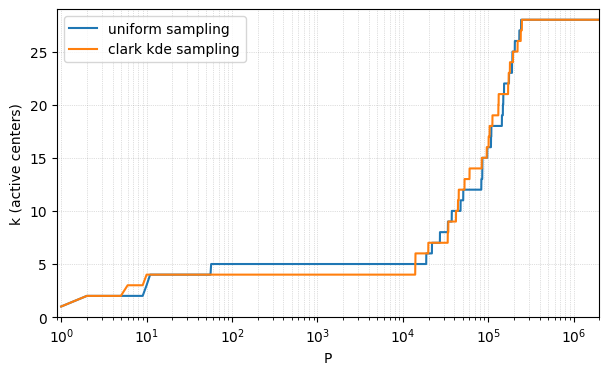

In [28]:
%%time
k_uniform = k_of_P_curve_numba(assignment,N_c)
k_clark = k_of_P_curve_numba(assignment_clark,N_c)

P_axis = np.arange(1, P_max+1)
fig, ax = plt.subplots(figsize=(7,4))
ax.set_xscale('log'); 
#ax.set_yscale('log')
ax.set_xlim(0,P_max); ax.set_ylim(0,N_c+1)
ax.grid(which='both', axis='both', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.plot(P_axis, k_uniform, label='uniform sampling')
ax.plot(P_axis, k_clark, label='clark kde sampling')
ax.set_xlabel('P')
ax.set_ylabel('k (active centers)')
ax.legend()